In [524]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [525]:
applications = pd.read_csv("applications.csv")
candidates = pd.read_csv("candidates.csv")
companies  = pd.read_csv("companies.csv")
interviews = pd.read_csv("interviews.csv")
jobs      = pd.read_csv("jobs.csv")
offers    = pd.read_csv("offers.csv")

In [743]:
companies.shape

(320, 5)

### Checking the Basic Structure

In [527]:
applications.head()

,application_id,job_id,candidate_id,applied_at,source,stage,score
0,1,1841,6949,2025-10-22 22:54:51,job_board,applied,0.920
1,2,1510,1387,2025-07-18 01:17:20,linkedin,interview,0.525
2,3,1945,7960,2026-01-06 18:49:32,job_board,applied,0.474
3,4,1823,7384,2025-10-09 01:22:15,linkedin,interview,0.587
4,5,1839,6407,2025-11-16 03:14:55,recruiter,applied,0.403


In [528]:
application.shape

(15000, 7)

In [745]:
interviews.shape

(7196, 5)

In [529]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  15000 non-null  int64  
 1   job_id          15000 non-null  int64  
 2   candidate_id    15000 non-null  int64  
 3   applied_at      15000 non-null  object 
 4   source          15000 non-null  object 
 5   stage           15000 non-null  object 
 6   score           15000 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 820.4+ KB


### checking the missing values

In [531]:
applications.isnull().sum()

application_id    0
job_id            0
candidate_id      0
applied_at        0
source            0
stage             0
score             0
dtype: int64

## checking duplicates

In [533]:
applications.duplicated().sum()

0

## Check unique values in categorical columns

In [535]:
applications['source'].value_counts()

source
job_board    7094
referral     2694
linkedin     2648
outbound     1333
recruiter    1231
Name: count, dtype: int64

In [536]:
applications['stage'].value_counts()

stage
applied      8638
screened     2792
interview    2632
offer         938
Name: count, dtype: int64

## Check the numerical score

In [538]:
applications['score'].describe()

count    15000.000000
mean         0.666598
std          0.182840
min          0.350000
25%          0.508000
50%          0.668000
75%          0.827000
max          0.980000
Name: score, dtype: float64

## Check the dates

In [540]:
applications['applied_at'].dtype

dtype('O')

In [541]:
applications['applied_at'].min(), applications['applied_at'].max()

('2024-01-03 10:50:13', '2026-02-13 03:52:44')

## Check IDs

In [543]:
print(applications['application_id'].nunique())
print(applications['job_id'].nunique())
print(applications['candidate_id'].nunique())

15000
2000
7324


## Convert applied_at to datetime

In [545]:
applications['applied_at'] = pd.to_datetime(
    applications['applied_at'],
    errors='coerce'
)

In [546]:
applications['applied_at'].dtype

dtype('<M8[ns]')

In [547]:
applications['applied_at'].isna().sum()

0

In [548]:
applications['application_date'] = applications['applied_at'].dt.date

applications['application_month'] = applications['applied_at'].dt.month

applications['application_year'] = applications['applied_at'].dt.year

applications['application_month_year'] = (
    applications['applied_at'].dt.to_period('M').astype(str)
)

In [549]:
applications.head()

,application_id,job_id,candidate_id,applied_at,source,stage,score,application_date,application_month,application_year,application_month_year
0,1,1841,6949,2025-10-22 22:54:51,job_board,applied,0.920,2025-10-22,10,2025,2025-10
1,2,1510,1387,2025-07-18 01:17:20,linkedin,interview,0.525,2025-07-18,7,2025,2025-07
2,3,1945,7960,2026-01-06 18:49:32,job_board,applied,0.474,2026-01-06,1,2026,2026-01
3,4,1823,7384,2025-10-09 01:22:15,linkedin,interview,0.587,2025-10-09,10,2025,2025-10
4,5,1839,6407,2025-11-16 03:14:55,recruiter,applied,0.403,2025-11-16,11,2025,2025-11


In [550]:
print(applications['applied_at'].dtype)
print(applications['applied_at'].isna().sum())

datetime64[ns]
0


In [551]:
import os
os.getcwd()

'C:\\Users\\anand\\ML\\US IT Recruitment project'

In [552]:
import os

os.makedirs('data/processed', exist_ok=True)

In [553]:
os.path.exists('data/processed')

True

In [554]:
applications_clean = applications.copy()
applications_clean.to_csv(
    'data/processed/applications_clean.csv',
    index=False
)

## Candidates data

In [556]:
candidates.head()

,candidate_id,candidate_name,years_experience,current_city,top_skill_area,summary
0,1,Terry Coffey,2,Atlanta,support,Led multi-region ERP rollout across three ware...
1,2,Seth Brock,5,Remote,analytics,Managed high-volume healthcare recruiting for ...
2,3,Bernard Webster,17,Remote,support,Built dbt models and Airflow pipelines for fin...
3,4,Michael Craig,4,Atlanta,engineering,Negotiated software procurement and vendor sav...
4,5,Ryan Grant,9,Remote,engineering,"Implemented Okta and SCIM provisioning for 2,0..."


In [557]:
candidates.shape

(9000, 6)

In [558]:
candidates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   candidate_id      9000 non-null   int64 
 1   candidate_name    9000 non-null   object
 2   years_experience  9000 non-null   int64 
 3   current_city      9000 non-null   object
 4   top_skill_area    9000 non-null   object
 5   summary           9000 non-null   object
dtypes: int64(2), object(4)
memory usage: 422.0+ KB


In [559]:
candidates.describe()

,candidate_id,years_experience
count,9000.000000,9000.000000
mean,4500.500000,8.546333
std,2598.220545,5.219556
min,1.000000,0.000000
25%,2250.750000,4.000000
50%,4500.500000,9.000000
75%,6750.250000,13.000000
max,9000.000000,17.000000


In [560]:
candidates.isnull().sum()

candidate_id        0
candidate_name      0
years_experience    0
current_city        0
top_skill_area      0
summary             0
dtype: int64

In [561]:
candidates.duplicated().sum()

0

In [562]:
print(candidates['years_experience'].max())
print(candidates['years_experience'].min())

17
0


In [563]:
candidates.nunique()

candidate_id        9000
candidate_name      8512
years_experience      18
current_city           6
top_skill_area         6
summary               24
dtype: int64

In [564]:
candidates['candidate_name'].str.strip().eq(candidates['candidate_name']).value_counts()

candidate_name
True    9000
Name: count, dtype: int64

In [565]:
candidates['current_city'].unique()

array(['Atlanta', 'Remote', 'Austin', 'Chicago', 'Seattle', 'Denver'],
      dtype=object)

In [566]:
candidates['candidate_name'].duplicated().sum()

488

In [567]:
## Standardize text fields
candidates['candidate_name'] = candidates['candidate_name'].str.strip()

candidates['current_city'] = candidates['current_city'].str.strip()

candidates['top_skill_area'] = candidates['top_skill_area'].str.strip()

In [568]:
candidates[['candidate_name', 'current_city', 'top_skill_area']].head()

,candidate_name,current_city,top_skill_area
0,Terry Coffey,Atlanta,support
1,Seth Brock,Remote,analytics
2,Bernard Webster,Remote,support
3,Michael Craig,Atlanta,engineering
4,Ryan Grant,Remote,engineering


In [569]:
candidates['years_experience'] = pd.to_numeric(
    candidates['years_experience'],
    errors='coerce'
)

In [570]:
candidates['years_experience'].isna().sum()

0

In [571]:
## useful ecperience buckets
candidates['experience_bucket'] = pd.cut(
    candidates['years_experience'],
    bins = [-1,2,5,10,float('inf')],
    labels = ['0-2 years','3-5 years','6-10 years','10+ years'])

In [572]:
candidates['experience_bucket'].value_counts()

experience_bucket
10+ years     3537
6-10 years    2485
0-2 years     1535
3-5 years     1443
Name: count, dtype: int64

In [573]:
candidates_clean = candidates.copy()

In [574]:
candidates_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\candidates_clean.csv',
    index=False
)

In [575]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\candidates_clean.csv'
)

True

## Jobs table

In [577]:
jobs.head(2)

,job_id,company_id,posted_at,title,role_family,level,location_type,employment_type,salary_low,salary_high,status
0,1,183,2024-01-01 08:36:25,Lifecycle Marketing Manager,operations,senior,remote,full_time,109000,126000,closed
1,2,184,2024-01-01 13:30:59,Lifecycle Marketing Manager,operations,junior,remote,full_time,66000,82000,closed


In [578]:
print(jobs.info())
print(jobs.shape)
print(jobs.isnull().sum())
print(jobs.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           2000 non-null   int64 
 1   company_id       2000 non-null   int64 
 2   posted_at        2000 non-null   object
 3   title            2000 non-null   object
 4   role_family      2000 non-null   object
 5   level            2000 non-null   object
 6   location_type    2000 non-null   object
 7   employment_type  2000 non-null   object
 8   salary_low       2000 non-null   int64 
 9   salary_high      2000 non-null   int64 
 10  status           2000 non-null   object
dtypes: int64(4), object(7)
memory usage: 172.0+ KB
None
(2000, 11)
job_id             0
company_id         0
posted_at          0
title              0
role_family        0
level              0
location_type      0
employment_type    0
salary_low         0
salary_high        0
status             0
dtype: in

In [579]:
jobs['role_family'].value_counts()

role_family
operations          991
engineering         425
data                302
product             128
customer_success     77
sales                77
Name: count, dtype: int64

In [580]:
jobs['level'].value_counts()

level
senior    748
mid       739
lead      260
junior    253
Name: count, dtype: int64

In [581]:
jobs['location_type'].value_counts()

location_type
remote    860
hybrid    692
onsite    448
Name: count, dtype: int64

In [582]:
jobs['employment_type'].value_counts()

employment_type
full_time    1757
contract      183
part_time      60
Name: count, dtype: int64

In [583]:
jobs['status'].value_counts()

status
filled    917
open      569
closed    344
paused    170
Name: count, dtype: int64

In [584]:
jobs[['salary_low', 'salary_high']].describe()

,salary_low,salary_high
count,2000.000000,2000.00000
mean,117845.500000,143147.50000
std,31834.483613,38576.36338
min,58000.000000,70000.00000
25%,91000.000000,112000.00000
50%,114000.000000,138000.00000
75%,135250.000000,166000.00000
max,206000.000000,253000.00000


In [585]:
jobs['salary_low'].min(), jobs['salary_high'].max()

(58000, 253000)

In [586]:
print(jobs.isnull().sum())
print(jobs['employment_type'].value_counts())
print(jobs['status'].value_counts())
print(jobs[['salary_low', 'salary_high']].describe())

job_id             0
company_id         0
posted_at          0
title              0
role_family        0
level              0
location_type      0
employment_type    0
salary_low         0
salary_high        0
status             0
dtype: int64
employment_type
full_time    1757
contract      183
part_time      60
Name: count, dtype: int64
status
filled    917
open      569
closed    344
paused    170
Name: count, dtype: int64
          salary_low   salary_high
count    2000.000000    2000.00000
mean   117845.500000  143147.50000
std     31834.483613   38576.36338
min     58000.000000   70000.00000
25%     91000.000000  112000.00000
50%    114000.000000  138000.00000
75%    135250.000000  166000.00000
max    206000.000000  253000.00000


In [587]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           2000 non-null   int64 
 1   company_id       2000 non-null   int64 
 2   posted_at        2000 non-null   object
 3   title            2000 non-null   object
 4   role_family      2000 non-null   object
 5   level            2000 non-null   object
 6   location_type    2000 non-null   object
 7   employment_type  2000 non-null   object
 8   salary_low       2000 non-null   int64 
 9   salary_high      2000 non-null   int64 
 10  status           2000 non-null   object
dtypes: int64(4), object(7)
memory usage: 172.0+ KB


In [588]:
## convert posted_at to datetime
jobs['posted_at'] = pd.to_datetime(
    jobs['posted_at'],
    errors='coerce'
)

In [589]:
jobs['posted_at'].dtype

dtype('<M8[ns]')

In [590]:
jobs['salary_low'] = pd.to_numeric(jobs['salary_low'], errors='coerce')
jobs['salary_high'] = pd.to_numeric(jobs['salary_high'], errors='coerce')

In [591]:
jobs[['salary_low', 'salary_high']].isna().sum()

salary_low     0
salary_high    0
dtype: int64

In [592]:
jobs['salary_midpoint'] = (
    jobs['salary_low'] + jobs['salary_high']
) / 2

In [593]:
jobs[['salary_low', 'salary_high', 'salary_midpoint']].head()

,salary_low,salary_high,salary_midpoint
0,109000,126000,117500.0
1,66000,82000,74000.0
2,92000,106000,99000.0
3,88000,111000,99500.0
4,90000,111000,100500.0


In [594]:
jobs['posted_date'] = jobs['posted_at'].dt.date

jobs['posted_month'] = jobs['posted_at'].dt.month

jobs['posted_year'] = jobs['posted_at'].dt.year

jobs['posted_month_year'] = (
jobs['posted_at'].dt.to_period('M').astype(str))

In [595]:
jobs['salary_range'] = (
    jobs['salary_high'] - jobs['salary_low']
)

In [596]:
jobs_clean = jobs.copy()

In [597]:
jobs_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\jobs_clean.csv',
    index=False
)

In [598]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\jobs_clean.csv'
)

True

## companies table

In [600]:
companies.head()

,company_id,company_name,industry,company_size,hq_city
0,1,"Rodriguez, Figueroa and Sanchez",software,startup,Austin
1,2,Doyle Ltd,fintech,enterprise,Denver
2,3,"Mcclain, Miller and Henderson",fintech,startup,Boston
3,4,Davis and Sons,logistics,startup,Chicago
4,5,"Guzman, Hoffman and Baldwin",logistics,growth,Boston


In [601]:
companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_id    320 non-null    int64 
 1   company_name  320 non-null    object
 2   industry      320 non-null    object
 3   company_size  320 non-null    object
 4   hq_city       320 non-null    object
dtypes: int64(1), object(4)
memory usage: 12.6+ KB


In [602]:
companies.duplicated().sum()

0

In [603]:
companies.isnull().sum()

company_id      0
company_name    0
industry        0
company_size    0
hq_city         0
dtype: int64

In [604]:
for i in companies[['company_name','industry','company_size','hq_city']]:
    counts = []
    counts = companies[i].value_counts()
    print(counts)

company_name
Davis and Sons                     2
Jones Inc                          2
Rodriguez, Figueroa and Sanchez    1
Stewart Ltd                        1
Terry-Martinez                     1
                                  ..
Dickson-Brady                      1
Wright, Garcia and Deleon          1
Nolan and Sons                     1
Nolan-Flynn                        1
Shaw, Nelson and Martin            1
Name: count, Length: 318, dtype: int64
industry
logistics     78
fintech       77
software      63
healthcare    53
retail        49
Name: count, dtype: int64
company_size
growth        125
enterprise    109
startup        86
Name: count, dtype: int64
hq_city
Atlanta    62
Boston     59
Denver     55
Seattle    51
Austin     49
Chicago    44
Name: count, dtype: int64


In [605]:
companies_clean = companies.copy()

In [606]:
companies_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\companies_clean.csv',
    index=False
)

In [607]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\companies_clean.csv'
)

True

## interviews table

In [609]:
interviews.head()

,interview_id,application_id,round_name,scheduled_at,result
0,1,2,panel,2025-07-31 01:17:20,pass
1,2,2,panel,2025-08-10 01:17:20,fail
2,3,2,hiring_manager,2025-08-07 01:17:20,pass
3,4,4,hiring_manager,2025-10-19 01:22:15,fail
4,5,8,hiring_manager,2025-05-28 01:49:44,pass


In [610]:
interviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7196 entries, 0 to 7195
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   interview_id    7196 non-null   int64 
 1   application_id  7196 non-null   int64 
 2   round_name      7196 non-null   object
 3   scheduled_at    7196 non-null   object
 4   result          7196 non-null   object
dtypes: int64(2), object(3)
memory usage: 281.2+ KB


In [611]:
interviews.isnull().sum()

interview_id      0
application_id    0
round_name        0
scheduled_at      0
result            0
dtype: int64

In [612]:
interviews.duplicated().sum()

0

In [613]:
print(interviews['interview_id'].nunique())
print(interviews['application_id'].nunique())

7196
3570


In [614]:
## converting scheduled_at into datetime
interviews['scheduled_at'] = pd.to_datetime(interviews['scheduled_at'], errors='coerce')

In [615]:
interviews['scheduled_at'].dtype

dtype('<M8[ns]')

In [616]:
interviews['round_name'].value_counts()

round_name
recruiter         1842
hiring_manager    1794
panel             1792
final             1768
Name: count, dtype: int64

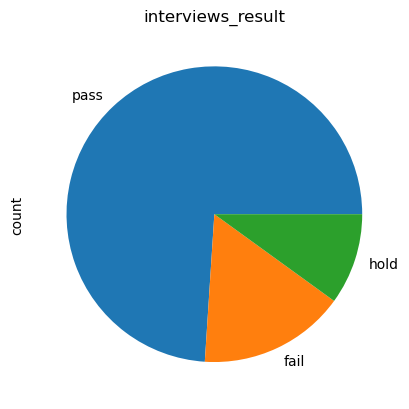

In [617]:
interviews['result'].value_counts().plot(kind = 'pie')
plt.title("interviews_result")
plt.show()

In [618]:
interviews_clean = interviews.copy()

In [619]:
interviews_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\interviews_clean.csv',
    index=False
)

In [620]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\companies_clean.csv'
)

True

## offers table

In [622]:
offers.head()

,offer_id,application_id,offered_at,base_salary,accepted,accepted_at
0,1,8,2025-06-24 01:49:44,130303,True,2025-06-01 01:49:44
1,2,13,2025-01-31 20:46:02,207647,True,2025-02-24 20:46:02
2,3,25,2024-12-01 02:55:22,168168,False,NaN
3,4,29,2025-05-27 06:18:41,105156,True,2025-06-02 06:18:41
4,5,30,2026-01-03 10:31:40,137936,True,2026-01-07 10:31:40


In [623]:
offers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   offer_id        938 non-null    int64 
 1   application_id  938 non-null    int64 
 2   offered_at      938 non-null    object
 3   base_salary     938 non-null    int64 
 4   accepted        938 non-null    bool  
 5   accepted_at     699 non-null    object
dtypes: bool(1), int64(3), object(2)
memory usage: 37.7+ KB


In [624]:
offers.isnull().sum()

offer_id            0
application_id      0
offered_at          0
base_salary         0
accepted            0
accepted_at       239
dtype: int64

In [625]:
offers[offers['accepted_at'].isnull()]

,offer_id,application_id,offered_at,base_salary,accepted,accepted_at
2,3,25,2024-12-01 02:55:22,168168,False,NaN
10,11,136,2025-11-20 14:12:06,104486,False,NaN
14,15,213,2025-03-10 22:59:06,147328,False,NaN
19,20,261,2025-04-13 08:11:49,140026,False,NaN
26,27,358,2024-12-25 20:08:45,98760,False,NaN
...,...,...,...,...,...,...
917,918,14699,2025-05-25 11:34:48,187187,False,NaN
919,920,14738,2024-08-05 02:03:08,96905,False,NaN
926,927,14854,2025-06-11 15:20:45,146278,False,NaN
927,928,14875,2024-12-30 12:39:42,201171,False,NaN


In [626]:
offers.duplicated().sum()

0

In [627]:
## convert offered_at to datetime
offers['offered_at'] = pd.to_datetime(offers['offered_at'],errors = 'coerce')

In [628]:
offers['accepted_at'] = pd.to_datetime(offers['accepted_at'],errors = 'coerce')

In [629]:
offers['offered_at'].dtype

dtype('<M8[ns]')

In [630]:
offers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   offer_id        938 non-null    int64         
 1   application_id  938 non-null    int64         
 2   offered_at      938 non-null    datetime64[ns]
 3   base_salary     938 non-null    int64         
 4   accepted        938 non-null    bool          
 5   accepted_at     699 non-null    datetime64[ns]
dtypes: bool(1), datetime64[ns](2), int64(3)
memory usage: 37.7 KB


In [631]:
print(offers['base_salary'].min())
print(offers['base_salary'].max())

61321
240017


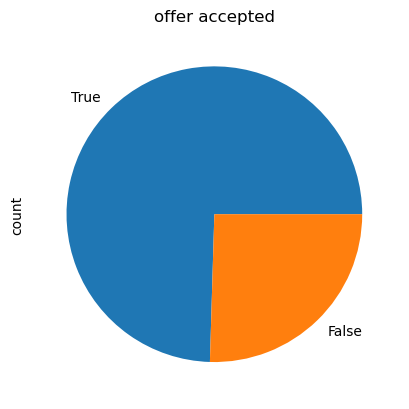

In [632]:
offers['accepted'].value_counts().plot(kind = 'pie')
plt.title('offer accepted')
plt.show()

In [633]:
offers['acceptance_status'] = offers['accepted_at'].notna().map({
    True: 'Accepted',
    False: 'Not Accepted'
})

In [634]:
acceptance_rate = offers['accepted_at'].notna().mean() * 100
print(f"Acceptance Rate: {acceptance_rate:.2f}%")

Acceptance Rate: 74.52%


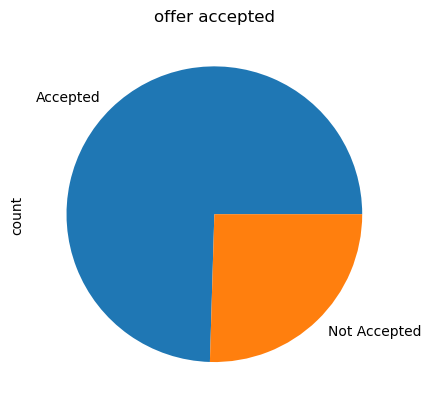

In [635]:
offers['acceptance_status'].value_counts().plot(kind = 'pie')
plt.title('offer accepted')
plt.show()

In [636]:
offers.isnull().sum()

offer_id               0
application_id         0
offered_at             0
base_salary            0
accepted               0
accepted_at          239
acceptance_status      0
dtype: int64

In [637]:
offers_clean = offers.copy()

In [638]:
offers_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\offers_clean.csv',
    index=False
)

In [639]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\companies_clean.csv'
)

True

In [747]:
offers['accepted'].value_counts(dropna=False)

accepted
True     699
False    239
Name: count, dtype: int64

In [749]:
offers['accepted'] = offers['accepted'].map({
    True: 1,
    False: 0
})

In [751]:
offers['accepted'].value_counts(dropna=False)

accepted
1    699
0    239
Name: count, dtype: int64

In [795]:
offers_clean = offers.copy()

In [797]:
offers_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\offers_clean.csv',
    index=False
)

In [757]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\companies_clean.csv'
)

True

In [759]:
offers['accepted'].value_counts(dropna=False)

accepted
1    699
0    239
Name: count, dtype: int64

In [761]:
offers[['offer_id', 'accepted', 'acceptance_status']].tail(10)

,offer_id,accepted,acceptance_status
928,929,1,Accepted
929,930,1,Accepted
930,931,1,Accepted
931,932,1,Accepted
932,933,0,Not Accepted
933,934,1,Accepted
934,935,1,Accepted
935,936,1,Accepted
936,937,1,Accepted
937,938,1,Accepted


In [763]:
offers[['offer_id', 'accepted', 'accepted_at', 'acceptance_status']].head(10)

,offer_id,accepted,accepted_at,acceptance_status
0,1,1,2025-06-01 01:49:44,Accepted
1,2,1,2025-02-24 20:46:02,Accepted
2,3,0,NaT,Not Accepted
3,4,1,2025-06-02 06:18:41,Accepted
4,5,1,2026-01-07 10:31:40,Accepted
5,6,1,2024-04-04 19:22:44,Accepted
6,7,1,2025-07-03 12:26:08,Accepted
7,8,1,2025-12-10 22:42:07,Accepted
8,9,1,2024-12-03 21:01:11,Accepted
9,10,1,2024-02-25 10:50:13,Accepted


In [765]:
offers[['offer_id', 'accepted', 'accepted_at', 'acceptance_status']].tail(10)

,offer_id,accepted,accepted_at,acceptance_status
928,929,1,2025-11-12 01:45:59,Accepted
929,930,1,2024-03-21 07:37:23,Accepted
930,931,1,2024-05-31 14:44:11,Accepted
931,932,1,2025-03-06 05:13:27,Accepted
932,933,0,NaT,Not Accepted
933,934,1,2024-11-06 22:45:35,Accepted
934,935,1,2024-04-21 00:56:02,Accepted
935,936,1,2024-09-23 23:08:51,Accepted
936,937,1,2025-03-30 21:57:46,Accepted
937,938,1,2024-07-02 16:25:59,Accepted


In [767]:
offers['accepted_at'] = offers['accepted_at'].replace({pd.NaT: None})

In [773]:
offers[['offer_id', 'accepted', 'accepted_at', 'acceptance_status']].tail(10)

,offer_id,accepted,accepted_at,acceptance_status
928,929,1,2025-11-12 01:45:59,Accepted
929,930,1,2024-03-21 07:37:23,Accepted
930,931,1,2024-05-31 14:44:11,Accepted
931,932,1,2025-03-06 05:13:27,Accepted
932,933,0,None,Not Accepted
933,934,1,2024-11-06 22:45:35,Accepted
934,935,1,2024-04-21 00:56:02,Accepted
935,936,1,2024-09-23 23:08:51,Accepted
936,937,1,2025-03-30 21:57:46,Accepted
937,938,1,2024-07-02 16:25:59,Accepted


In [771]:
offers['accepted_at'] = offers['accepted_at'].where(
    offers['accepted_at'].notna(),
    None
)

In [789]:
offers_clean = offers.copy()

In [791]:
offers_clean.to_csv(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\offers_clean.csv',
    index=False
)

In [779]:
os.path.exists(
    r'C:\Users\anand\ML\US IT Recruitment project\data\processed\companies_clean.csv'
)

True

In [781]:
offers[['offer_id', 'accepted', 'accepted_at', 'acceptance_status']].tail(10)

,offer_id,accepted,accepted_at,acceptance_status
928,929,1,2025-11-12 01:45:59,Accepted
929,930,1,2024-03-21 07:37:23,Accepted
930,931,1,2024-05-31 14:44:11,Accepted
931,932,1,2025-03-06 05:13:27,Accepted
932,933,0,None,Not Accepted
933,934,1,2024-11-06 22:45:35,Accepted
934,935,1,2024-04-21 00:56:02,Accepted
935,936,1,2024-09-23 23:08:51,Accepted
936,937,1,2025-03-30 21:57:46,Accepted
937,938,1,2024-07-02 16:25:59,Accepted


In [793]:
offers['accepted_at'] = offers['accepted_at'].replace(
    '________',
    pd.NaT
)

offers['accepted_at'] = pd.to_datetime(
    offers['accepted_at'],
    errors='coerce'
)

offers['accepted_at'] = offers['accepted_at'].dt.strftime(
    '%Y-%m-%d %H:%M:%S'
)

offers['accepted_at'] = offers['accepted_at'].fillna('NULL')

In [783]:
offers['accepted_at'] = pd.to_datetime(
    offers['accepted_at'],
    errors='coerce'
)

In [785]:
offers['accepted_at'].isna().sum()

239

In [787]:
offers['accepted_at'] = offers['accepted_at'].dt.strftime(
    '%Y-%m-%d %H:%M:%S'
)

offers['accepted_at'] = offers['accepted_at'].fillna('')